In [1]:
import pandas as pd

### Loading the Dataset

I'll load the `winequality-red.csv` dataset into a Pandas DataFrame for further analysis.

In [20]:
df = pd.read_csv('/winequality-red.csv', sep=';', quotechar='"')

### Handling Missing Values

First, I'll check for any missing values in the dataset. If found, they will be replaced with the mean of their respective columns to maintain data integrity for further analysis.

In [21]:
# Check for missing values
missing_values_before = df.isnull().sum()
print("Missing values before handling:")
display(missing_values_before[missing_values_before > 0])

# Handle missing values by replacing null values with the mean of the respective column
for column in df.columns:
    if df[column].isnull().any():
        df[column].fillna(df[column].mean(), inplace=True)

print("\nMissing values after handling:")
missing_values_after = df.isnull().sum()
display(missing_values_after[missing_values_after > 0])

print("\nFirst 5 rows of the DataFrame after handling missing values:")
display(df.head())

Missing values before handling:


,0



Missing values after handling:


,0



First 5 rows of the DataFrame after handling missing values:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Feature Selection and Covariance Matrix Calculation

I'll select the 'alcohol' and 'density' features and calculate their covariance matrix, which is a key step in Principal Component Analysis (PCA).

In [22]:
import numpy as np

# Select two features: alcohol and density
alcohol_feature = df['alcohol']
density_feature = df['density']

# Create a feature matrix X for covariance calculation
# X now has shape (1599, 2) where rows are observations and columns are features
X = df[['alcohol', 'density']].values

# Calculate the covariance matrix using np.cov(X.T) as requested.
# X.T will have shape (2, 1599) where rows are features and columns are observations.
cov_matrix = np.cov(X.T)

print("Selected features (first 5 rows):")
display(df[['alcohol', 'density']].head())

print("\nCovariance Matrix:")
display(pd.DataFrame(cov_matrix, index=['alcohol', 'density'], columns=['alcohol', 'density']))

Selected features (first 5 rows):


,alcohol,density
0,9.4,0.9978
1,9.8,0.9968
2,9.8,0.9970
3,9.8,0.9980
4,9.4,0.9978



Covariance Matrix:


,alcohol,density
alcohol,1.135647,-0.000998
density,-0.000998,0.000004


### Eigen Decomposition

Now, I'll perform eigen decomposition on the covariance matrix. This step will yield the eigenvalues and eigenvectors, which represent the variance explained by each principal component and the directions of these components, respectively.

In [23]:
# Perform eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Eigenvalues:")
display(sorted_eigenvalues)

print("\nEigenvectors (column by column, corresponding to sorted eigenvalues):")
display(pd.DataFrame(sorted_eigenvectors, index=['alcohol', 'density'], columns=['PC1', 'PC2']))

print("\nTop 2 Eigenvalues:")
display(sorted_eigenvalues[:2])

print("\nCorresponding Eigenvectors:")
display(pd.DataFrame(sorted_eigenvectors[:, :2], index=['alcohol', 'density'], columns=['PC1', 'PC2']))

Eigenvalues:


array([1.13564827e+00, 2.68507580e-06])


Eigenvectors (column by column, corresponding to sorted eigenvalues):


,PC1,PC2
alcohol,1.000000,0.000879
density,-0.000879,1.000000



Top 2 Eigenvalues:


array([1.13564827e+00, 2.68507580e-06])


Corresponding Eigenvectors:


,PC1,PC2
alcohol,1.000000,0.000879
density,-0.000879,1.000000


### Extracting Features as Vectors

I'll now extract the 'alcohol' and 'citric acid' columns from the DataFrame `df` as individual vectors for further inspection or use.

In [24]:
alcohol_vector = df['alcohol']
citric_acid_vector = df['citric acid']

print("Alcohol vector (first 5 values):")
display(alcohol_vector.head())

print("\nCitric acid vector (first 5 values):")
display(citric_acid_vector.head())

Alcohol vector (first 5 values):


,alcohol
0,9.4
1,9.8
2,9.8
3,9.8
4,9.4



Citric acid vector (first 5 values):


,citric acid
0,0.00
1,0.00
2,0.04
3,0.56
4,0.00


### Wine Quality Distribution Analysis

To understand the wine quality scores, I will first determine the frequency of each quality rating. This will help identify the most common quality score. Subsequently, I will visualize this distribution using a bar chart for better interpretation of the quality ratings across the dataset.

In [25]:
# Calculate the frequency of each wine quality score
quality_counts = df['quality'].value_counts().sort_index()

print("Frequency of each wine quality score:")
display(quality_counts)

# Identify the most common wine quality
most_common_quality = quality_counts.idxmax()
most_common_count = quality_counts.max()

print(f"\nThe most common wine quality in the dataset is '{most_common_quality}' with {most_common_count} occurrences.")

Frequency of each wine quality score:


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18



The most common wine quality in the dataset is '5' with 681 occurrences.


/tmp/ipykernel_1613/1257856039.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quality_counts.index, y=quality_counts.values, palette='viridis')


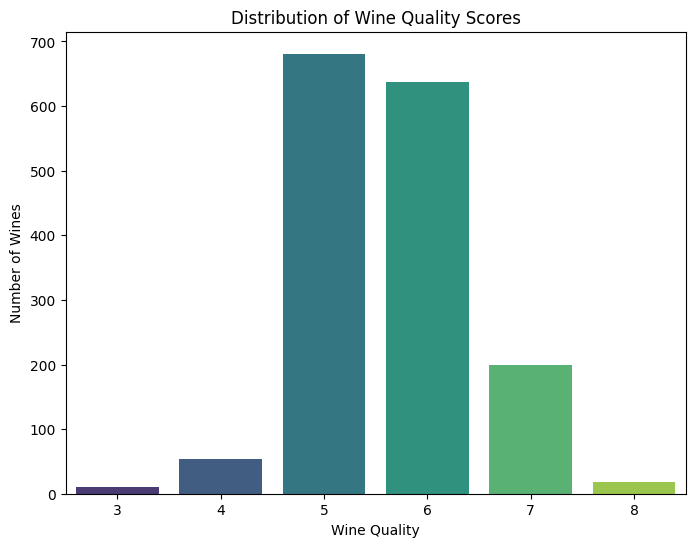

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of wine quality scores
plt.figure(figsize=(8, 6))
sns.barplot(x=quality_counts.index, y=quality_counts.values, palette='viridis')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Wine Quality')
plt.ylabel('Number of Wines')
plt.show()